In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([

    [80,3],
    [120,3],
    [100,2],
    [150,4]

])

Y = np.array([310,390,325,530])

X_bias = np.c_[np.ones((4,1)),X]

A_saludable = X_bias.T @ X_bias
b = X_bias.T @ Y


In [6]:
pies2 = X[:,0] * 10.764

X_enfermo = np.c_[X, pies2]

X_enfermo_bias = np.c_[np.ones((4,1)), X_enfermo]

In [ ]:
A_enfermo = X_enfermo_bias.T @ X_enfermo_bias
b = X_enfermo_bias.T @ Y    
            

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [10]:
A_pinv = np.linalg.pinv(A_enfermo)
print(A_pinv)

[[ 5.73684211e+00 -2.25183615e-04 -8.42105263e-01 -2.42387643e-03]
 [-2.25185573e-04  5.13838303e-08 -1.50122082e-04  5.53095549e-07]
 [-8.42105263e-01 -1.50122410e-04  9.38596491e-01 -1.61591762e-03]
 [-2.42387624e-03  5.53094813e-07 -1.61591765e-03  5.95351256e-06]]


In [12]:
theta = A_pinv @ b
print(theta)

[-1.18421053e+01  2.12423269e-02  4.04385965e+01  2.28652342e-01]


In [14]:
predicciones = X_enfermo_bias @ theta
print(f"Precios originales{Y}")
print(f"Predicciones del modelo enfermo: {np.round(predicciones,2)}")

Precios originales[310 390 325 530]
Predicciones del modelo enfermo: [308.07 407.37 317.28 522.28]


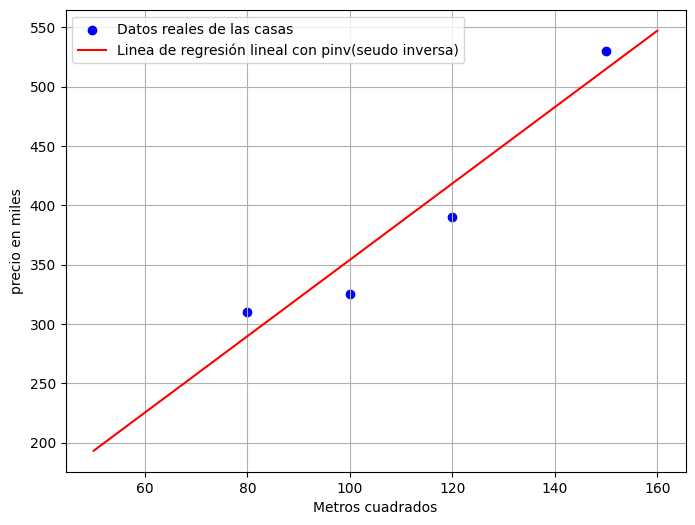

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(X_enfermo[:,0],Y, color = 'blue', label='Datos reales de las casas')
X_linea = np.array([[50],[160]])
X_linea_bias = np.c_[np.ones((2,1)),X_linea, np.array([[2,538],[4, 1722]])]
y_linea_prediccion = X_linea_bias @ theta
plt.plot(X_linea, y_linea_prediccion, color ='red', label ='Linea de regresión lineal con pinv(seudo inversa)')
plt.xlabel('Metros cuadrados')
plt.ylabel('precio en miles')
plt.grid(True)
plt.legend()
plt.show()